## Python version 11.

In [9]:
!pip install pandas langdetect deep_translator spacy underthesea nltk matplotlib seaborn openpyxl
!python -m spacy download en_core_web_md

     ---------------------------------------- 0.0/33.5 MB ? eta -:--:--
     ---------------------------------------- 0.3/33.5 MB ? eta -:--:--
      --------------------------------------- 0.8/33.5 MB 2.1 MB/s eta 0:00:16
      --------------------------------------- 0.8/33.5 MB 2.1 MB/s eta 0:00:16
     - -------------------------------------- 1.0/33.5 MB 1.4 MB/s eta 0:00:24
     - -------------------------------------- 1.3/33.5 MB 1.5 MB/s eta 0:00:23
     -- ------------------------------------- 1.8/33.5 MB 1.5 MB/s eta 0:00:22
     -- ------------------------------------- 2.1/33.5 MB 1.6 MB/s eta 0:00:21
     --- ------------------------------------ 2.6/33.5 MB 1.6 MB/s eta 0:00:20
     --- ------------------------------------ 3.1/33.5 MB 1.7 MB/s eta 0:00:18
     ---- ----------------------------------- 3.4/33.5 MB 1.7 MB/s eta 0:00:18
     ---- ----------------------------------- 3.7/33.5 MB 1.7 MB/s eta 0:00:18
     ---- ----------------------------------- 3.9/33.5 MB 1.7 MB/s

In [10]:
# Import các thư viện cần thiết
import pandas as pd
from langdetect import detect
from deep_translator import GoogleTranslator
import re
import spacy
from underthesea import word_tokenize, pos_tag
from nltk.corpus import stopwords
import numpy as np
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

In [11]:
nlp_en = spacy.load('en_core_web_md')
stop_words_en = None
stop_words_vi = None

In [12]:
# Đường dẫn đến file csv chứa các job description
csv_jd = "../../data/raw/itviec_jobs_undetected.csv"
stop_words_vn_txt = "../../docs/vietnamese-stopwords.txt"
json_topcv = "../../data/raw/topcv_it_jobs.json"
skills_link = "../../data/skills.txt"

In [13]:
df = pd.read_csv(csv_jd)
df_topcv = pd.read_json(json_topcv)

In [14]:
skills_list = df['skills'].unique()
print(skills_list)

['MLOps, Python, Linux, Docker, Data Science, TensorFlow, DataOps / MLOps Engineer, Financial Services'
 'AWS, DevOps, Cloud, Cloud-native Architecture, AWS CloudFormation, CI/CD, Cloud Engineer, Financial Services'
 'Project Management, Business Analysis, Presale, Project Manager, IT Services and IT Consulting'
 'Presale, Business Analysis, Salesforce, Pre-sales Engineer, Telecommunication'
 'Embedded, C++, Linux, C language, Embedded Engineer, Telecommunication'
 'PQA, Team Management, QA QC, ISO 27001, IT Audit, Manager, IT Services and IT Consulting, Software Development Outsourcing, Software Products and Web Services'
 'Bridge Project Management, Japanese, Agile, Project Management, DevOps, Bridge System Engineer (BrSE), Software Development Outsourcing'
 'PQA, QA QC, Tester, ISO 27001, IT Audit, Governance, Risk & Compliance, Test Coordinator / QAQC Coordinator, Banking, IT Services and IT Consulting, Securities & Investment, Financial Services'
 'NodeJS, Java, PHP, OOP, CI/CD, B

In [15]:
combined_skills = ','.join(skills_list)

# Bước 2: Tách thành mảng các kỹ năng riêng lẻ
split_skills = [skill.strip() for skill in combined_skills.split(',')]

# Bước 3: Lấy các giá trị duy nhất
unique_skills = np.unique(split_skills)
print(unique_skills)


['.NET' '3ds Max' 'AI' 'AI / Machine Learning Engineer' 'API' 'AWS'
 'AWS CloudFormation' 'Adobe' 'Advertising and Entertainment' 'Agile'
 'Android' 'Angular' 'Application Security Engineer' 'Automation Test'
 'Automation Tester' 'Axure' 'Azure' 'BI Analyst / BI Developer' 'BRD'
 'Backend Developer' 'Balsamiq' 'Banking'
 'Banking & Financial Systems Developer' 'Big Data' 'Big Data Engineer'
 'Blockchain' 'Blockchain Developer' 'Blockchain and Deep Tech Services'
 'Bridge Project Management' 'Bridge System Engineer (BrSE)'
 'Business Analysis' 'Business Analyst' 'Business Intelligence'
 'C language' 'C#' 'C++' 'C-level (CTO' 'CDO)' 'CI/CD' 'CIO' 'CISO' 'CRM'
 'CSS' 'Cisco' 'Cloud' 'Cloud Engineer' 'Cloud-native Architecture'
 'Creative and Design' 'Cyber Security' 'Cybersecurity' 'Dart'
 'Data Analysis' 'Data Analyst' 'Data Architect' 'Data Engineer'
 'Data Governance Specialist' 'Data Science' 'Data Scientist'
 'Data Warehousing' 'DataOps / MLOps Engineer' 'Database'
 'Database Adminis

In [16]:
job_categories = [
    'AI / Machine Learning Engineer',
    'Application Security Engineer',
    'Automation Tester',
    'Backend Developer',
    'Banking & Financial Systems Developer',
    'BI Analyst / BI Developer',
    'Big Data Engineer',
    'Blockchain Developer',
    'Bridge System Engineer (BrSE)',
    'Business Analyst',
    'C-level (CTO',
    'CDO)',
    'CIO',
    'CISO',
    'Cloud Engineer',
    'Data Analyst',
    'Data Architect',
    'Data Engineer',
    'Data Governance Specialist',
    'Data Scientist',
    'DataOps / MLOps Engineer',
    'Database Administrator',
    'Desktop Application Developer',
    'DevOps Engineer',
    'DevSecOps',
    'DevSecOps Engineer',
    'Embedded Engineer',
    'Enterprise Application Developer (CRM)',
    'ERP Consultant',
    'ERP Developer',
    'Frontend Developer',
    'Fullstack Developer',
    'Game Designer',
    'Game Developer',
    'IT Administrator',
    'IT Auditor / IT Risk Manager',
    'IT Communication/Translation',
    'IT Consultant',
    'IT Support',
    'Japanese IT Communication',
    'Mobile Application Developer',
    'Motion Designer',
    'Network Engineer',
    'Performance / Load Tester',
    'Pre-sales Engineer',
    'Product Designer',
    'Product Manager',
    'Product Owner',
    'Program Manager / PMO',
    'Project Manager',
    'QA QC',
    'RPA Engineer',
    'Scrum Master / Agile Coach',
    'Security Consultant',
    'Security Engineer',
    'Security Tester / Penetration Tester',
    'Site Reliability Engineer (SRE)',
    'Software Engineer in Test (SDET)',
    'Software/Technical Architect',
    'Solution Architect',
    'SysOps Engineer',
    'Systems Engineer / Administrator',
    'Technical Consultant',
    'Technical Writer',
    'Test Coordinator / QAQC Coordinator',
    'UX Researcher',
    'UX/UI Designer',
    'Vice President / Director',
    'Visual / Graphic Designer'
]

In [17]:
# Đầu tiên, tạo cột category rỗng nếu chưa có
df['category'] = ''

for index, row in df.iterrows():
    skills = [s.strip() for s in row['skills'].split(',')]
    categories_in_row = set()  # Dùng set để tránh trùng lặp
    
    for skill in skills:
        # Kiểm tra nếu skill trùng với bất kỳ job category nào
        for job in job_categories:
            if skill.lower() == job.lower():  # So sánh không phân biệt hoa thường
                categories_in_row.add(job)
                break 
    
    # Nối các categories tìm được vào cột category
    if categories_in_row:
        df.at[index, 'category'] = ','.join(categories_in_row)


In [18]:
df['category'].unique()

array(['DataOps / MLOps Engineer', 'Cloud Engineer', 'Project Manager',
       'Pre-sales Engineer', 'Embedded Engineer', 'QA QC',
       'Bridge System Engineer (BrSE)',
       'QA QC,Test Coordinator / QAQC Coordinator', 'Backend Developer',
       'Frontend Developer', 'Fullstack Developer', 'Network Engineer',
       'C-level (CTO,CIO,CISO,CDO)', 'Vice President / Director',
       'Mobile Application Developer',
       'Banking & Financial Systems Developer', 'Data Engineer',
       'Data Engineer,Product Manager', 'Automation Tester',
       'IT Auditor / IT Risk Manager',
       'Japanese IT Communication,Business Analyst',
       'Systems Engineer / Administrator', 'ERP Consultant',
       'Database Administrator', 'Big Data Engineer', 'DevOps Engineer',
       'IT Support,IT Communication/Translation,IT Administrator',
       'Application Security Engineer', 'Data Analyst',
       'Japanese IT Communication,Bridge System Engineer (BrSE)',
       'Game Developer', 'Security Eng

In [19]:
new_rows = []

for _, json_row in df_topcv.iterrows():
    new_row = {}

    for col in df.columns:
        if col == 'requirements':
            # Nếu cột 'requirements' có tồn tại trong json_row
            if 'requirements' in json_row and isinstance(json_row['requirements'], list):
                new_row[col] = ', '.join(json_row['requirements'])
            else:
                new_row[col] = json_row.get('requirements', None)
        else:
            new_row[col] = json_row.get(col, None)

    new_rows.append(new_row)

# Thêm tất cả dòng mới vào df
df = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)



In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            995 non-null    object
 1   title         2513 non-null   object
 2   company       2513 non-null   object
 3   location      2513 non-null   object
 4   salary        2513 non-null   object
 5   work_type     995 non-null    object
 6   description   2513 non-null   object
 7   requirements  2513 non-null   object
 8   skills        995 non-null    object
 9   category      2513 non-null   object
dtypes: object(10)
memory usage: 196.5+ KB


In [21]:
df['category'].unique()

array(['DataOps / MLOps Engineer', 'Cloud Engineer', 'Project Manager',
       'Pre-sales Engineer', 'Embedded Engineer', 'QA QC',
       'Bridge System Engineer (BrSE)',
       'QA QC,Test Coordinator / QAQC Coordinator', 'Backend Developer',
       'Frontend Developer', 'Fullstack Developer', 'Network Engineer',
       'C-level (CTO,CIO,CISO,CDO)', 'Vice President / Director',
       'Mobile Application Developer',
       'Banking & Financial Systems Developer', 'Data Engineer',
       'Data Engineer,Product Manager', 'Automation Tester',
       'IT Auditor / IT Risk Manager',
       'Japanese IT Communication,Business Analyst',
       'Systems Engineer / Administrator', 'ERP Consultant',
       'Database Administrator', 'Big Data Engineer', 'DevOps Engineer',
       'IT Support,IT Communication/Translation,IT Administrator',
       'Application Security Engineer', 'Data Analyst',
       'Japanese IT Communication,Bridge System Engineer (BrSE)',
       'Game Developer', 'Security Eng

In [22]:
category_mapping = {
    "Front‑end Developer": [
        "Frontend Developer",
        "Front end Developer",
        "Frontend DeveloperIT - Phần mềm",
        "Frontend DeveloperNghỉ thứ 7",
        "Frontend DeveloperAn ninh mạng",
        "Front‑end DeveloperIT - Phần mềmNghỉ thứ 7",
        "Front‑end DeveloperIT - Phần mềm",
        "Front‑end",
        "Front - end Desinge",           
    ],

    "Back‑end Developer": [
        "Backend Developer",
        "Backend DeveloperIT - Phần mềm",
        "Backend DeveloperNghỉ thứ 7",
        "Backend DeveloperIT - Phần mềmTài chính",
        "Backend DeveloperNhà hàng / Khách sạn",
    ],

    "Full‑stack Developer": [
        "Fullstack Developer",
        "Fullstack DeveloperIT - Phần mềm",
        "Fullstack DeveloperNghỉ thứ 7",
        "Fullstack DeveloperTài chính",
        "Fullstack DeveloperIT - Phần mềmGameTài chính",
        "Fullstack",                      
        "Fullstack DeveloperIT - Phần mềmGame",
        "Fullstack DeveloperIT - Phần mềmNghỉ thứ 7",
    ],

    # ─────────────────────────── Mobile ──────────────────────────────
    "Mobile Developer": [
        "Mobile Developer",
        "Mobile DeveloperIT - Phần mềm",
        "Mobile DeveloperNghỉ thứ 7",
        "Mobile DeveloperIT - Phần mềmGame",
        "Mobile DeveloperIT - Phần mềmTài chính",
    ],

    # ─────────────────────────── DevOps / MLOps / SysOps ─────────────
    "DevOps / MLOps / SysOps": [
        "DevOps",
        "DevOps Engineer",
        "DevOps EngineerIT - Phần mềm",
        "DevOps EngineerNghỉ thứ 7",
        "DevOps EngineerBảo hiểmTài chính",
        "SysOps Engineer",
        "MLOps",
        "Cloud Engineer",
        "Cloud EngineerIT - Phần mềm",
        "Cloud EngineerNghỉ thứ 7",
        "AWS CloudFormation",
        "Azure",
        "IoT", 
        "Cloud EngineerĐiện toán đám mây (Cloud)",# thường gộp chung Cloud/DevOps ở VN
    ],

    # ─────────────────────────── Data ‑ AI family ────────────────────
    "Data / AI": [
        "Data Engineer",
        "Data Science",  # thiếu
    "Big Data", 
        "Data EngineerIT - Phần mềm",
        "Data EngineerIT - Phần mềmNghỉ thứ 7",
        "Big Data Engineer",
        "Data EngineerAn ninh mạngNgân hàng",
        "Data Analyst",
        "Data Analysis",
        "Data AnalystIT - Phần mềm",
        "Data AnalystIT - Phần mềmNghỉ thứ 7",
        "Data AnalystTài chínhChứng khoán",
        "Data AnalystMarketing / Quảng cáo",
        "Data Scientist",
        "Data ScientistIT - Phần mềm",
        "Data ScientistIT - Phần mềmNghỉ thứ 7",
        "Data ScientistIT - Phần mềmNgân hàng",
        "AI",
        "AI Engineer",
        "AI EngineerIT - Phần mềm",
        "AI EngineerIT - Phần mềmNghỉ thứ 7",
        "AI EngineerIT - Phần mềmTài chính",
        "AI EngineerIT - Phần mềmViễn thông",
        "AI Researcher",
        "AI ResearcherTài chínhChứng khoán",
        "Big Data",
        "TensorFlow",
        "Data Governance Specialist",
        "Data Labeling (Gán nhãn dữ liệu)",
    ],

    # ─────────────────────────── QA / Test ───────────────────────────
    "QA / Tester": [
        "Tester",
        "QA Engineer",
        "QA EngineerIT - Phần mềm",
        "QA EngineerNghỉ thứ 7",
        "QA EngineerIT - Phần cứng và máy tính",
        "Manual Tester",
        "Manual TesterIT - Phần mềm",
        "Manual TesterIT - Phần mềmNgân hàng",
        "Manual TesterNghỉ thứ 7",
        "Automation Tester",
        "Automation TesterIT - Phần mềmNghỉ thứ 7",
        "Software Tester (Automation & Manual)",
        "Process Quality Assurance (PQA)",
        "Game TesterGameIT - Phần mềmNghỉ thứ 7",
        "Manual TesterIT - Phần cứng và máy tính", # thiếu
    "Data AnalystIT - Phần cứng và máy tính",  
    ],

    # ─────────────────────────── Project / Product ───────────────────
    "Project & Product Management": [
        "Project Management",
        "IT Project Manager",
        "IT Project ManagerNghỉ thứ 7",
        "IT Project ManagerIT - Phần mềm",
        "IT Project ManagerTài chínhNgân hàng",
        "Project ManagerNghỉ thứ 7",
        "Technical Project Manager",   # giả định
        "Product Management",
        "Product Owner",
        "Product Owner/Product Manager",
        "Product Owner/Product ManagerNghỉ thứ 7",
        "Product Owner/Product ManagerTài chính",
        "Product Owner/Product ManagerChứng khoán",
        "Product Analyst/Research",
        "Product Analyst/ResearchIT - Phần mềm",
    ],

    # ─────────────────────────── Security / Network ───────────────────
    "Security & Network": [
        "Security",
        "System Administrator",
        "System AdministratorIT - Phần mềm",
        "Network Engineer",
        "Network EngineerAn ninh mạng",
        "Network EngineerTiếng Trung HSK 4",
        "Chuyên viên IT Security",
        "Chuyên viên Cyber SecurityAn ninh mạng",
        "Quản trị và vận hành bảo mật",
        "Mã hóa và bảo mật dữ liệuAn ninh mạng",
        "Phòng chống lừa đảo và an ninh mạng",
        "Kiểm thử và đánh giá bảo mật",
        "Tuân thủ và kiểm toán bảo mật",
        "IT Security",  # rút gọn
        "System AdministratorNghỉ thứ 7",          # thiếu
    "Network EngineerNghỉ thứ 7",              # thiếu
    "Chuyên viên Cyber SecurityIT - Phần mềm",
    ],

    # ─────────────────────────── Game Development ────────────────────
    "Game Development": [
        "Game Developer",
        "Game DeveloperIT - Phần mềm",
        "Game DeveloperIT - Phần mềmGame",
        "Game DeveloperNghỉ thứ 7",
        "Vị trí Game Development khác",
        "Vị trí Game Development khácGame",
        "Vị trí Game Development khácNghỉ thứ 7",
        "Game Design",
        "Game DesignNghỉ thứ 7",
        "Game DesignIT - Phần mềmGame",
        "Game DesignGameIT - Phần mềmNghỉ thứ 7",
        "Concept Artist",
        "Concept ArtistIT - Phần mềmGame",
        "Concept ArtistGame",
        "Concept ArtistNghỉ thứ 7",
        "IllustrationGameIT - Phần mềm",
        "3D ModelerGame",
        "Animation DesignGame",
        "Game Designer", # thiếu  
    "Game TesterNghỉ thứ 7",  # thiếu
    "3D ModelerNghỉ thứ 7", 
    ],

    # ─────────────────────────── UI / UX / Design ────────────────────
    "UI‑UX / Graphic Design": [
        "UI/UX Design",
        "UI/UX DesignIT - Phần mềm",
        "UI/UX DesignNghỉ thứ 7",
        "UI/UX DesignThiết kế / Kiến trúc",
        "UI/UX DesignIT - Phần mềmGame",
        "UI/UX DesignIT - Phần mềmTài chính",
        "Thiết kế đồ họa (Graphic Design)",
        "Thiết kế đồ họa (Graphic Design)Game",
        "Thiết kế đồ họa (Graphic Design)Báo chí",
        "Thiết kế đồ họa (Graphic Design)Du lịch",
        "Thiết kế đồ họa (Graphic Design)Xây dựng",
        "Animation Design",
        "Animation DesignNghỉ thứ 7",
        "Animation DesignGame",
        "Motion Designer",
        "Visual / Graphic Designer",
        "Illustration",
        "IllustrationThiết kế / Kiến trúc",
        "Interaction Design",
        "Interaction Designer",
         "3D Modeler",  # thiếu
    "3D ModelerThiết kế / Kiến trúc", # thiếu
    "3D ModelerMarketing / Quảng cáo", # thiếu
    "3D ModelerThiết kế / Kiến trúcNghỉ thứ 7", # thiếu
    "IllustrationMarketing / Quảng cáo", # thiếu
    "IllustrationIn ấn / Xuất bản",     # thiếu
    "IllustrationGameNghỉ thứ 7",       # thiếu
    "Concept ArtistThiết kế / Kiến trúc", # thiếu
    "Concept ArtistGameMarketing / Quảng cáo", # thiếu
    "Animation DesignMarketing / Quảng cáo",   # thiếu
    "Animation DesignGameThiết kế / Kiến trúc", # thiếu
    "Animation DesignIT - Phần mềmGame",       # thiếu
    "Animation DesignGameNghỉ thứ 7",          # thiếu
    "Interaction DesignerThiết kế / Kiến trúc",
    ],

    # ─────────────────────────── Dev‑Sec‑Ops / SysAdmin ───────────────
    "SysAdmin / Infrastructure": [
        "SysOps Engineer",
        "System Engineer",
        "System EngineerNghỉ thứ 7",
        "System EngineerIT - Phần mềm",
        "System Admin",
        "System AdministratorNghỉ thứ 7",
        "System Architecture",
        "System EngineerIT - Phần mềm",  # thiếu
    "System AdministratorIT - Phần mềm", #
    ],

    # ─────────────────────────── Misc. kỹ thuật nhúng / embedded ─────
    "Embedded / IoT": [
        "Embedded Engineer",
        "Embedded Engineer/Lập trình nhúng",
        "Robotics Software Engineer",
        "BIM Engineer",
        "BIM EngineerNghỉ thứ 7",
        "BIM EngineerXây dựng",
        "Embedded",
        "IoT",
        "Robotics Software Engineer",
        "BIM EngineerXây dựngThiết kế / Kiến trúc", # thiếu
    "BIM EngineerĐiện / Điện tử / Điện lạnh",   # thiếu
    "BIM EngineerIT - Phần cứng và máy tính",   # thiếu
    "BIM EngineerThiết kế / Kiến trúc", 
    ],
    
    # ─────────────────────────── Business / BA / Analyst ──────────────
    "Business Analysis / BA": [
        "Business Analysis",
        "Business Analyst (Phân tích nghiệp vụ)",
        "Business Analyst / Research",
        "Business AnalysisIT - Phần mềm",  # nếu có
    ],
    
# ===== 1. Software Engineer / General Development =====
"Software Engineer": [
    "Software Engineer",
    "Software EngineerIT - Phần mềm", 
    "Software EngineerIT - Phần mềmNghỉ thứ 7",
    "Software EngineerNghỉ thứ 7",
    "Software EngineerIT - Phần mềmTài chính",
]
,
# ===== 2. Technical Leadership =====
"Technical Leadership": [
    "Technical Leader",
    "Technical LeaderIT - Phần mềm",
    "Technical LeaderIT - Phần mềmNghỉ thứ 7", 
    "Technical LeaderNghỉ thứ 7",
    "Technical LeaderIT - Phần mềmNgân hàng",
    "Technical LeaderIT - Phần mềmGame",
    "Technical LeaderIT - Phần mềmViễn thông",
    "Technical LeaderIT - Phần mềmBảo hiểm",
    "Technical Manager",
    "Technical ManagerNghỉ thứ 7",
    "Technical ManagerIT - Phần mềmNghỉ thứ 7",
    "Technical DirectorIT - Phần mềm",
    "Chief Technology Officer (CTO)",
]
,
# ===== 3. Database / DBA =====
"Database Administration": [
    "Database Administrator (DBA)",
    "Database Administrator (DBA)Nghỉ thứ 7",
]
,
# ===== 4. Blockchain =====
"Blockchain Development": [
    "Blockchain Developer",
    "Blockchain EngineerIT - Phần mềm", 
    "Blockchain EngineerAn ninh mạng",
]
,
# ===== 5. Software Architecture =====  
"Software Architecture": [
    "Software ArchitectIT - Phần mềm",
    "Software ArchitectXây dựng",
    "Solution ArchitectNghỉ thứ 7",
]
,
# ===== 6. IT Support / Helpdesk =====
"IT Support": [
    "IT Support",
    "IT Helpdesk/IT support", 
    "IT Helpdesk/IT supportIT - Phần mềm",
]
,
# =,==== 7. IT Consultant =====
"IT Consulting": [
    "IT Consultant",
    "IT ConsultantIT - Phần cứng và máy tính",
    "IT ConsultantIT - Phần mềmNghỉ thứ 7",
    "IT ConsultantAn ninh mạng",
    "IT ConsultantTài chínhKế toán",
    "IT ConsultantNghỉ thứ 7",
]
,
# ===== 8. Desktop Application =====
"Desktop Development": [
    "Desktop Application Developer",
]
,
# ===== 9. Enterprise Applications =====
"Enterprise Development": [
    "Enterprise Application Developer (CRM)",
    "ERP Developer",
    "Banking & Financial Systems Developer",
    "Integration & Legacy Systems Developer",
    "Tích hợp hệ thống",
]
,
# ===== 10. Technical Writing =====
"Technical Writing": [
    "Technical Writer",
]
,
# ===== 11. RPA =====
"RPA Development": [
    "RPA Engineer",
]
,
# ===== 12. Outsourcing =====
"Software Outsourcing": [
    "Software Development Outsourcing",
]
,
# ===== 13. Agile / Scrum =====
"Agile / Scrum": [
    "Scrum MasterNghỉ thứ 7",
    "Scrum MasterThương mại điện tửNghỉ thứ 7",
]
,
# ===== 14. Kỹ thuật IT / Hardware =====
"IT Technical / Hardware": [
    "Kỹ thuật IT",
    "Kỹ thuật ITIT - Phần mềm",
    "Kỹ thuật ITIT - Phần mềmNghỉ thứ 7", 
    "Kỹ thuật ITIT - Phần cứng và máy tính",
    "Kỹ thuật ITĐiện / Điện tử / Điện lạnh",
    "Kỹ sư cơ điệnIT - Phần cứng và máy tính",
    "Kỹ sư điện tửIT - Phần cứng và máy tính", 
    "Kỹ sư điệnĐiện / Điện tử / Điện lạnh",
    "Kỹ sư điện tử viễn thông",
    "Kỹ sư mạngAn ninh mạng",
]
,
# ===== 15. Bridge Engineer (BrSE) =====
"Bridge Engineer": [
    "Kỹ sư cầu nối BrSE",
    "Kỹ sư cầu nối BrSEIT - Phần mềm",
    "Kỹ sư cầu nối BrSENghỉ thứ 7",
]
,
# ===== 16. IT Comtor =====
"IT Comtor": [
    "IT ComtorIT - Phần mềmNghỉ thứ 7",
    "IT ComtorIT - Phần mềm", 
    "IT ComtorNghỉ thứ 7Tiếng Nhật JLPT N2",
    "IT ComtorIT - Phần mềmTiếng Nhật JLPT N2",
]

    # Bạn có thể tiếp tục thêm các nhóm khác tuỳ ý...
}


In [23]:
def map_category(raw_cat: str) -> str | None:
    for canon, variants in category_mapping.items():
        if raw_cat in variants:
            return canon
    return None  # chưa khớp

df["category"] = df["category"].apply(map_category)



In [24]:
df['category'].unique()

array([None, 'DevOps / MLOps / SysOps', 'Embedded / IoT',
       'Back‑end Developer', 'Front‑end Developer',
       'Full‑stack Developer', 'Security & Network',
       'Enterprise Development', 'Data / AI', 'QA / Tester',
       'Game Development', 'Technical Writing', 'RPA Development',
       'Project & Product Management', 'UI‑UX / Graphic Design',
       'Desktop Development', 'IT Support', 'IT Consulting',
       'Blockchain Development', 'IT Comtor', 'Database Administration',
       'Software Engineer', 'Business Analysis / BA',
       'Technical Leadership', 'Mobile Developer',
       'IT Technical / Hardware', 'SysAdmin / Infrastructure',
       'Bridge Engineer', 'Software Architecture', 'Agile / Scrum'],
      dtype=object)

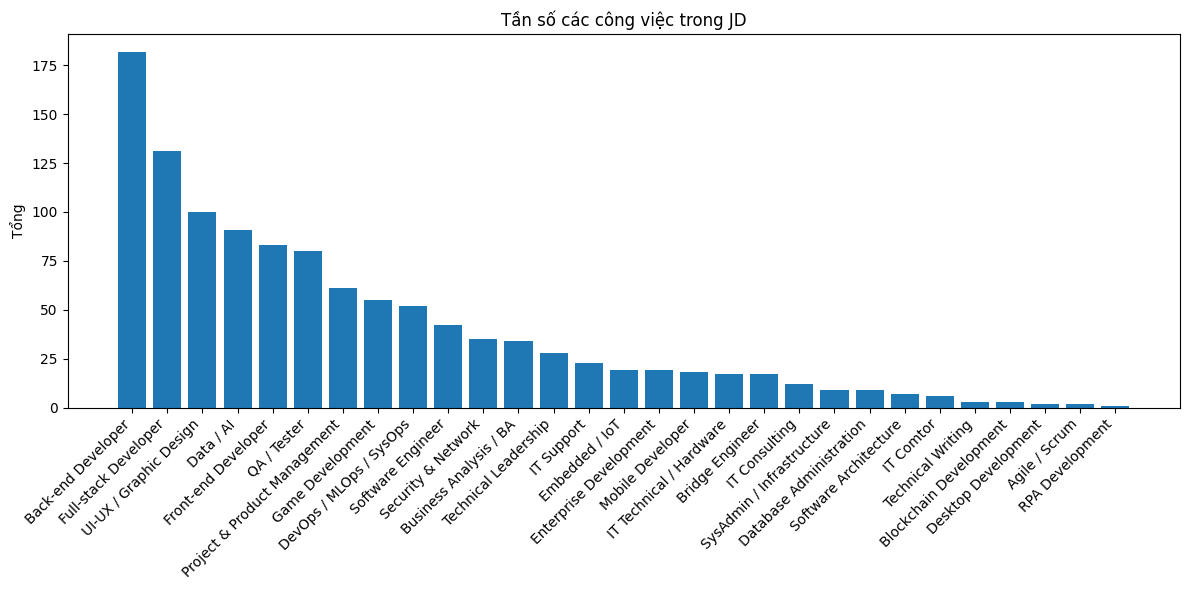

In [25]:
df_filtered = df.dropna(subset=['category'])

# Bước 2: Tách riêng 'UI‑UX / Graphic Design' và giới hạn 150 dòng
ui_ux_mask = df_filtered['category'] == 'UI‑UX / Graphic Design'  # Kiểm tra lại dấu gạch ngang!
df_ui_ux = df_filtered[ui_ux_mask].head(100)

# Bước 3: Lấy tất cả các categories KHÁC (không phải UI‑UX)
df_other_categories = df_filtered[~ui_ux_mask]
df_final = pd.concat([df_ui_ux, df_other_categories])
# Vẽ biểu đồ cho tất cả categories (nhưng UI-UX chỉ có tối đa 150 dòng)
freq = df_final['category'].value_counts().rename_axis('Category').reset_index(name='Count')

plt.figure(figsize=(12, 6))
plt.bar(freq['Category'], freq['Count'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Tổng')
plt.title('Tần số các công việc trong JD')
plt.tight_layout()
plt.show()

=========

In [26]:
with open(stop_words_vn_txt, 'r', encoding='utf-8') as f:
    stop_words_vi = set(word.strip() for word in f if word.strip())
stop_words_en = set(stopwords.words('english'))

In [27]:
def detect_language(text):
    try:
        return detect(text)
    except:
        return 'unknown'


def translate_to_english(text, lang):
    try:
        if lang == 'en' or pd.isna(text) or text.strip() == "":
            return text
        return GoogleTranslator(source=lang, target='en').translate(text)
    except Exception as e:
        print(f"Error translating: {e} | text: {text}")
        return text
def clean_text_not_stopword(text):
    text = text.lower()
    text = re.sub(r'http\S+|#\S+|@\S+|[^\w\s]|\n|\r|\t|\*|\•', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_stopwords(text):
    tokens = text.split()
    cleaned = []

    for token in tokens:
        if token.isupper():
            cleaned.append(token)
            continue
        if token.lower() in stop_words_en or token.lower() in stop_words_vi:
            continue
        cleaned.append(token)
    return ' '.join(cleaned)



def clean_text(text, lang="en"):
    if not isinstance(text, str) or not text.strip():
        return ""
    
    protected = []
    def _protect(match):
        protected.append(match.group(0))
        return f"__PROT_{len(protected)-1}__"
    
    # Bảo vệ các thuật ngữ IT như C#, C++, node.js trước mọi xử lý
    text = re.sub(r"\b\w+[#+.]\w*\b", _protect, text, flags=re.IGNORECASE)
    
    # Các bước xử lý văn bản
    text = text.lower()
    text = re.sub(r"(?<=\b\w)[-/](?=\w\b)", " ", text)
    text = re.sub(r"\s*&\s*", " ", text)
    text = re.sub(r"http\S+|@\s|\s@(?=\s)|\s#", " ", text)
    text = re.sub(r"[()]", " ", text)
    text = re.sub(r"(?<!\w)[.,!?;:–—](?!\w)", " ", text)
    text = re.sub(r"[\n\r\t]", " ", text)
    text = re.sub(r"\b\w*['’‘]\w*\b", "", text)
    text = re.sub(r"\s*[-–—]{2,}\s*", " ", text)
    text = re.sub(r"[“”‘’«»„‟]", " ", text)
    text = re.sub(r"(?<=\w)[.,!:](?=\s|$)", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"/", " ", text)
    text = re.sub(r"(?<=\w):(?=\w)", " ", text)
    text = re.sub(r"([^a-zA-Z0-9\s])\1{2,}", "", text)
    
    
    # Khôi phục các thuật ngữ được bảo vệ
    for i, word in enumerate(protected):
        text = text.replace(f"__prot_{i}__", word.lower())
    
    return text

# Kiểm tra

def clean_skills(text):
    if text == None:
        return text
    text.lower()
    if pd.isna(text) or text.strip() == "":
        return []
    return [t.strip() for t in text.split(',') if t.strip()]

In [28]:
text = f''' we need skils C++, c# and python, node.js, java'''
print(clean_text(text))

we need skils c++ c# and python node.js java


In [29]:
pd.DataFrame(df)

,id,title,company,location,salary,work_type,description,requirements,skills,category
0,1,MLops Engineer,Trusting Social,Ho Chi Minh,You'll love it,Not specified,We are looking for qualified MLops Engineer fo...,BS or MS in Computer Science or related fields...,"MLOps, Python, Linux, Docker, Data Science, Te...",None
1,2,"Senior DevOps Engineer (Cloud, AWS)",TymeX,Ho Chi Minh,You'll love it,Not specified,We are seeking an experienced Senior DevOps En...,Requirements:\r\nBachelor's or Master's degree...,"AWS, DevOps, Cloud, Cloud-native Architecture,...",DevOps / MLOps / SysOps
2,3,VTS - Chuyên Viên Quản Trị Dự Án (Agile/ Azure),Viettel Group,Ha Noi,You'll love it,Not specified,Ecotek đang dẫn dắt Ecopark phát triển trở thà...,"Tư duy logic tốt, tư duy hướng giải pháp, tư d...","Project Management, Business Analysis, Presale...",None
3,4,VTS - Tư Vấn Giải Pháp - Presales Engineer,Viettel Group,Ha Noi,You'll love it,Not specified,"Gia nhập “vũ trụ” công nghệ Viettel, nơi bạn k...",Bằng cấp: Tốt nghiệp Đại học (loại Khá trở lên...,"Presale, Business Analysis, Salesforce, Pre-sa...",None
4,5,"VHT - Embedded Software Engineer (Linux, C++)",Viettel Group,Ha Noi,"650 - 2,200 USD",Not specified,"Với hơn 1200 nhân sự chất lượng cao , Tổng Côn...",Tốt nghiệp Đại học chính quy loại Khá trở lên ...,"Embedded, C++, Linux, C language, Embedded Eng...",Embedded / IoT
...,...,...,...,...,...,...,...,...,...,...
2508,None,CTV Quản Lý Dự Án,Công ty CP An ninh mạng Việt Nam,Hà Nội,Thoả thuận,None,--- Mô tả công việc ---\nTheo dõi kế hoạch dự ...,"Kỹ năng giao tiếp, Làm việc nhóm, Quản lý thời...",None,Project & Product Management
2509,None,Nhân Viên Thiết Kế (Designer),Công Ty TNHH Thương Mại - Dịch Vụ Hoa Mai,Hồ Chí Minh,10 - 15 triệu,None,--- Mô tả công việc ---\n- Chịu trách nhiệm ...,,None,UI‑UX / Graphic Design
2510,None,Nhân Viên Thiết Kế Đồ Họa,Công ty TNHH GONG CHA VIỆT NAM,Hồ Chí Minh,Thoả thuận,None,--- Mô tả công việc ---\nThiết kế key visuals ...,"Khả Năng Làm Việc Độc Lập Và Nhóm, Khả Năng Sá...",None,UI‑UX / Graphic Design
2511,None,Trợ Lý Kinh Doanh B2B,CÔNG TY TNHH DỊCH VỤ CÔNG NGHỆ THÔNG TIN HOÀNG...,Hồ Chí Minh,15 - 25 triệu,None,--- Mô tả công việc ---\nVai trò của bạn – Trợ...,"Giao tiếp hiệu quả, Kỹ Năng Tổ Chức Và Quản Lý...",None,None


In [30]:
df['language'] = df['description'].apply(detect_language)

In [31]:
df['description_clean'] = df.apply(lambda x: clean_text(x['description']), axis=1)
df['requirements_clean'] = df.apply(lambda x: clean_text(x['requirements']), axis=1)

In [32]:
pd.DataFrame(df)

,id,title,company,location,salary,work_type,description,requirements,skills,category,language,description_clean,requirements_clean
0,1,MLops Engineer,Trusting Social,Ho Chi Minh,You'll love it,Not specified,We are looking for qualified MLops Engineer fo...,BS or MS in Computer Science or related fields...,"MLOps, Python, Linux, Docker, Data Science, Te...",None,en,we are looking for qualified mlops engineer fo...,bs or ms in computer science or related fields...
1,2,"Senior DevOps Engineer (Cloud, AWS)",TymeX,Ho Chi Minh,You'll love it,Not specified,We are seeking an experienced Senior DevOps En...,Requirements:\r\nBachelor's or Master's degree...,"AWS, DevOps, Cloud, Cloud-native Architecture,...",DevOps / MLOps / SysOps,en,we are seeking an experienced senior devops en...,requirements or degree in computer science inf...
2,3,VTS - Chuyên Viên Quản Trị Dự Án (Agile/ Azure),Viettel Group,Ha Noi,You'll love it,Not specified,Ecotek đang dẫn dắt Ecopark phát triển trở thà...,"Tư duy logic tốt, tư duy hướng giải pháp, tư d...","Project Management, Business Analysis, Presale...",None,vi,ecotek đang dẫn dắt ecopark phát triển trở thà...,tư duy logic tốt tư duy hướng giải pháp tư duy...
3,4,VTS - Tư Vấn Giải Pháp - Presales Engineer,Viettel Group,Ha Noi,You'll love it,Not specified,"Gia nhập “vũ trụ” công nghệ Viettel, nơi bạn k...",Bằng cấp: Tốt nghiệp Đại học (loại Khá trở lên...,"Presale, Business Analysis, Salesforce, Pre-sa...",None,vi,gia nhập vũ trụ công nghệ viettel nơi bạn khôn...,bằng cấp tốt nghiệp đại học loại khá trở lên c...
4,5,"VHT - Embedded Software Engineer (Linux, C++)",Viettel Group,Ha Noi,"650 - 2,200 USD",Not specified,"Với hơn 1200 nhân sự chất lượng cao , Tổng Côn...",Tốt nghiệp Đại học chính quy loại Khá trở lên ...,"Embedded, C++, Linux, C language, Embedded Eng...",Embedded / IoT,vi,với hơn 1200 nhân sự chất lượng cao tổng công ...,tốt nghiệp đại học chính quy loại khá trở lên ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2508,None,CTV Quản Lý Dự Án,Công ty CP An ninh mạng Việt Nam,Hà Nội,Thoả thuận,None,--- Mô tả công việc ---\nTheo dõi kế hoạch dự ...,"Kỹ năng giao tiếp, Làm việc nhóm, Quản lý thời...",None,Project & Product Management,vi,mô tả công việc theo dõi kế hoạch dự án triển ...,kỹ năng giao tiếp làm việc nhóm quản lý thời g...
2509,None,Nhân Viên Thiết Kế (Designer),Công Ty TNHH Thương Mại - Dịch Vụ Hoa Mai,Hồ Chí Minh,10 - 15 triệu,None,--- Mô tả công việc ---\n- Chịu trách nhiệm ...,,None,UI‑UX / Graphic Design,vi,mô tả công việc - chịu trách nhiệm tạo dựng hì...,
2510,None,Nhân Viên Thiết Kế Đồ Họa,Công ty TNHH GONG CHA VIỆT NAM,Hồ Chí Minh,Thoả thuận,None,--- Mô tả công việc ---\nThiết kế key visuals ...,"Khả Năng Làm Việc Độc Lập Và Nhóm, Khả Năng Sá...",None,UI‑UX / Graphic Design,vi,mô tả công việc thiết kế key visuals cho các c...,khả năng làm việc độc lập và nhóm khả năng sán...
2511,None,Trợ Lý Kinh Doanh B2B,CÔNG TY TNHH DỊCH VỤ CÔNG NGHỆ THÔNG TIN HOÀNG...,Hồ Chí Minh,15 - 25 triệu,None,--- Mô tả công việc ---\nVai trò của bạn – Trợ...,"Giao tiếp hiệu quả, Kỹ Năng Tổ Chức Và Quản Lý...",None,None,vi,mô tả công việc vai trò của bạn trợ lý kinh do...,giao tiếp hiệu quả kỹ năng tổ chức và quản lý ...


In [33]:
df.to_excel('text.xlsx')

In [34]:
df['description_en_clean'] = df.apply(lambda x: translate_to_english(x['description_clean'], x['language']), axis=1)
df['requirements_en_clean'] = df.apply(lambda x: translate_to_english(x['requirements_clean'], x['language']), axis=1)

Error translating: mô tả công việc 1.quản lý vận hành hệ thống cơ sở dữ liệu csdl - tư vấn thiết kế xây dựng csdl;- thiết kế thiết lập các biện pháp tăng cường an ninh bảo mật cho csdl;- thiết kế xây dựng chiến lược sao lưu phục hồi csdl;- thiết kế xây dưng các chương trình script thực hiện giám sát hoạt động csdl phát hiện xử lý ngăn chặn kịp thời các sự cố vấn đề csdl;- nghiên cứu và đánh giá các hệ thống cơ sở dữ liệu và đưa ra các giải pháp tối ưu các biện pháp tinh chỉnh cho cơ sở dữ liệu;- phân tích xác định nguyên nhân các sự cố vấn đề liên quan đến csdl;- cập nhật các bản vá lỗi nâng cấp phiên bản csdl;- chuyển đổi quy hoạch hệ thống csdl tối ưu sử dụng tài nguyên phần cứng máy chủ cũng như đáp ứng yêu cầu hiệu năng của từng hệ thống ứng dụng báo cáo;2 tổ chức triển khai dự án dự án các công việc bảo trì hệ thống csdl tổ chức triển khai các hạng mục công việc của dự án cr theo đúng kế hoạch đã phê duyệt:- tổ chức hỗ trợ thực hiện xây dựng các yêu cầu kỹ thuật liên quan đến csdl

In [35]:
for i in range(len(df)):
    df.at[i, 'id'] = "JOB_" + str(i)


In [36]:
pd.DataFrame(df)

,id,title,company,location,salary,work_type,description,requirements,skills,category,language,description_clean,requirements_clean,description_en_clean,requirements_en_clean
0,JOB_0,MLops Engineer,Trusting Social,Ho Chi Minh,You'll love it,Not specified,We are looking for qualified MLops Engineer fo...,BS or MS in Computer Science or related fields...,"MLOps, Python, Linux, Docker, Data Science, Te...",None,en,we are looking for qualified mlops engineer fo...,bs or ms in computer science or related fields...,we are looking for qualified mlops engineer fo...,bs or ms in computer science or related fields...
1,JOB_1,"Senior DevOps Engineer (Cloud, AWS)",TymeX,Ho Chi Minh,You'll love it,Not specified,We are seeking an experienced Senior DevOps En...,Requirements:\r\nBachelor's or Master's degree...,"AWS, DevOps, Cloud, Cloud-native Architecture,...",DevOps / MLOps / SysOps,en,we are seeking an experienced senior devops en...,requirements or degree in computer science inf...,we are seeking an experienced senior devops en...,requirements or degree in computer science inf...
2,JOB_2,VTS - Chuyên Viên Quản Trị Dự Án (Agile/ Azure),Viettel Group,Ha Noi,You'll love it,Not specified,Ecotek đang dẫn dắt Ecopark phát triển trở thà...,"Tư duy logic tốt, tư duy hướng giải pháp, tư d...","Project Management, Business Analysis, Presale...",None,vi,ecotek đang dẫn dắt ecopark phát triển trở thà...,tư duy logic tốt tư duy hướng giải pháp tư duy...,Ecotek is leading Ecopark to become a smart ci...,Good logical thinking of thinking solutions to...
3,JOB_3,VTS - Tư Vấn Giải Pháp - Presales Engineer,Viettel Group,Ha Noi,You'll love it,Not specified,"Gia nhập “vũ trụ” công nghệ Viettel, nơi bạn k...",Bằng cấp: Tốt nghiệp Đại học (loại Khá trở lên...,"Presale, Business Analysis, Salesforce, Pre-sa...",None,vi,gia nhập vũ trụ công nghệ viettel nơi bạn khôn...,bằng cấp tốt nghiệp đại học loại khá trở lên c...,Joining the Viettel technology space where you...,Graduation degree with a good or higher degree...
4,JOB_4,"VHT - Embedded Software Engineer (Linux, C++)",Viettel Group,Ha Noi,"650 - 2,200 USD",Not specified,"Với hơn 1200 nhân sự chất lượng cao , Tổng Côn...",Tốt nghiệp Đại học chính quy loại Khá trở lên ...,"Embedded, C++, Linux, C language, Embedded Eng...",Embedded / IoT,vi,với hơn 1200 nhân sự chất lượng cao tổng công ...,tốt nghiệp đại học chính quy loại khá trở lên ...,With more than 1200 high quality personnel Vie...,"Graduated with a regular university or higher,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2508,JOB_2508,CTV Quản Lý Dự Án,Công ty CP An ninh mạng Việt Nam,Hà Nội,Thoả thuận,None,--- Mô tả công việc ---\nTheo dõi kế hoạch dự ...,"Kỹ năng giao tiếp, Làm việc nhóm, Quản lý thời...",None,Project & Product Management,vi,mô tả công việc theo dõi kế hoạch dự án triển ...,kỹ năng giao tiếp làm việc nhóm quản lý thời g...,Project description of project plan implementa...,Working skills in group management team manage...
2509,JOB_2509,Nhân Viên Thiết Kế (Designer),Công Ty TNHH Thương Mại - Dịch Vụ Hoa Mai,Hồ Chí Minh,10 - 15 triệu,None,--- Mô tả công việc ---\n- Chịu trách nhiệm ...,,None,UI‑UX / Graphic Design,vi,mô tả công việc - chịu trách nhiệm tạo dựng hì...,,Job description - Responsible for creating ima...,
2510,JOB_2510,Nhân Viên Thiết Kế Đồ Họa,Công ty TNHH GONG CHA VIỆT NAM,Hồ Chí Minh,Thoả thuận,None,--- Mô tả công việc ---\nThiết kế key visuals ...,"Khả Năng Làm Việc Độc Lập Và Nhóm, Khả Năng Sá...",None,UI‑UX / Graphic Design,vi,mô tả công việc thiết kế key visuals cho các c...,khả năng làm việc độc lập và nhóm khả năng sán...,Key Visuals design description for online camp...,The ability to work independently and the crea...
2511,JOB_2511,Trợ Lý Kinh Doanh B2B,CÔNG TY TNHH DỊCH VỤ CÔNG NGHỆ THÔNG TIN HOÀNG...,Hồ Chí Minh,15 - 25 triệu,None,--- Mô tả công việc ---\nVai trò của bạn – Trợ...,"Giao tiếp hiệu quả, Kỹ Năng Tổ Chức Và Quản Lý...",None,None,vi,mô tả công việc vai trò của bạn trợ lý kinh do

In [37]:
df = df[~df['description'].str.lower().str.strip().isin(['', 'no description available','not specified'])]
df = df[~df['requirements'].str.lower().str.strip().isin(['', 'no requirements specified','not specified'])]

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2081 entries, 0 to 2512
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2081 non-null   object
 1   title                  2081 non-null   object
 2   company                2081 non-null   object
 3   location               2081 non-null   object
 4   salary                 2081 non-null   object
 5   work_type              841 non-null    object
 6   description            2081 non-null   object
 7   requirements           2081 non-null   object
 8   skills                 841 non-null    object
 9   category               1305 non-null   object
 10  language               2081 non-null   object
 11  description_clean      2081 non-null   object
 12  requirements_clean     2081 non-null   object
 13  description_en_clean   2081 non-null   object
 14  requirements_en_clean  2081 non-null   object
dtypes: object(15)
memory usage

In [45]:
drop_columns = ['skills','skills_en']
df = df.drop(drop_columns, axis=1)

KeyError: "['skills_en'] not found in axis"

In [47]:
def read_skills(file_path):
    skills = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):
                skills.append(line.lower())
    return skills

skills_list = read_skills('../../data/skills.txt')

In [48]:
import re
from collections import Counter
import spacy

adj_counter = Counter()
adv_counter = Counter()

def clean_text_for_matching(text):
    if not isinstance(text, str) or not text.strip():
        return ""
    
    protected = []
    def _protect(match):
        protected.append(match.group(0))
        return f"__PROT_{len(protected)-1}__"
    
    # Bảo vệ các thuật ngữ IT như C#, C++, node.js trước mọi xử lý
    text = re.sub(r"\b\w+[#+.]\w*\b", _protect, text, flags=re.IGNORECASE)
    
    # Các bước xử lý văn bản
    text = text.lower()
    text = re.sub(r"(?<=\b\w)[-/](?=\w\b)", " ", text)
    text = re.sub(r"\s*&\s*", " ", text)
    text = re.sub(r"http\S+|@\s|\s@(?=\s)|\s#", " ", text)
    text = re.sub(r"[()]", " ", text)
    text = re.sub(r"(?<!\w)[.,!?;:–—](?!\w)", " ", text)
    text = re.sub(r"[\n\r\t]", " ", text)
    text = re.sub(r"\b\w*['’‘]\w*\b", "", text)
    text = re.sub(r"\s*[-–—]{2,}\s*", " ", text)
    text = re.sub(r"[“”‘’«»„‟]", " ", text)
    text = re.sub(r"(?<=\w)[.,!:](?=\s|$)", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"/", " ", text)
    text = re.sub(r"(?<=\w):(?=\w)", " ", text)
    text = re.sub(r"([^a-zA-Z0-9\s])\1{2,}", "", text)
    
    
    # Khôi phục các thuật ngữ được bảo vệ
    for i, word in enumerate(protected):
        text = text.replace(f"__prot_{i}__", word.lower())
    
    return text

def nomalize_skills(skills):
    return [clean_text_for_matching(skill).strip() for skill in skills]


skills_list = nomalize_skills(skills_list)
def generate_ngrams(text, max_n=3):
    tokens = text.split()
    ngrams = []
    for n in range(1, max_n+1):
        ngrams.extend([' '.join(tokens[i:i+n]) for i in range(len(tokens)-n+1)])
    return ngrams

def extract_skills(text):
    if not isinstance(text.lower(), str) or pd.isna(text.lower()):
        return []

    ngrams = generate_ngrams(text.lower(), max_n=3)

    found = [skill for skill in skills_list if skill in ngrams]

    return list(dict.fromkeys(found))



def extract_adjectives(text):
    if not isinstance(text, str) or pd.isna(text):
        return []

    doc = nlp_en(text)
    adjs = [
        token.lemma_.lower()
        for token in doc
        if token.pos_ == "ADJ"
        and len(token.lemma_) > 2            # loại từ ngắn như "as", "own"
        and token.is_alpha                   # bỏ từ chứa số, ký hiệu
        and not token.is_stop                # loại stop words mặc định của spaCy
    ]
    adj_counter.update(adjs)
    return list(set(adjs))

def extract_adverbs(text):
    if not isinstance(text, str) or pd.isna(text):
        return []

    doc = nlp_en(text)
    advs = [
        token.lemma_.lower()
        for token in doc
        if token.pos_ == "ADV"
        and len(token.lemma_) > 2
        and token.is_alpha
        and not token.is_stop
    ]
    adv_counter.update(advs)
    return list(set(advs))

In [49]:
nomalize_skills(['c#','PYTHON','PhP','Node.JS','Java'])

['c#', 'python', 'php', 'node.js', 'java']

In [50]:
df.loc[:, 'primary_skills'] = df.apply(
    lambda row: extract_skills(f"{row['requirements_en_clean'] or ''}"),
    axis=1
)

df.loc[:, 'secondary_skills'] = df.apply(
    lambda row: extract_skills(f"{row['description_en_clean'] or ''}"),
    axis=1
)

df.loc[:, 'adjectives'] = df.apply(
    lambda row: extract_adjectives(f"{row['requirements_en_clean'] or ''} {row['description_en_clean'] or ''}"),
    axis=1
)

df.loc[:, 'adverbs'] = df.apply(
    lambda row: extract_adverbs(f"{row['requirements_en_clean'] or ''} {row['description_en_clean'] or ''}"),
    axis=1
)




In [51]:
df.to_excel('text.xlsx')

C:\Users\DELL\AppData\Local\Temp\ipykernel_5272\1403453381.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Skill', data=skills_df, palette='viridis')


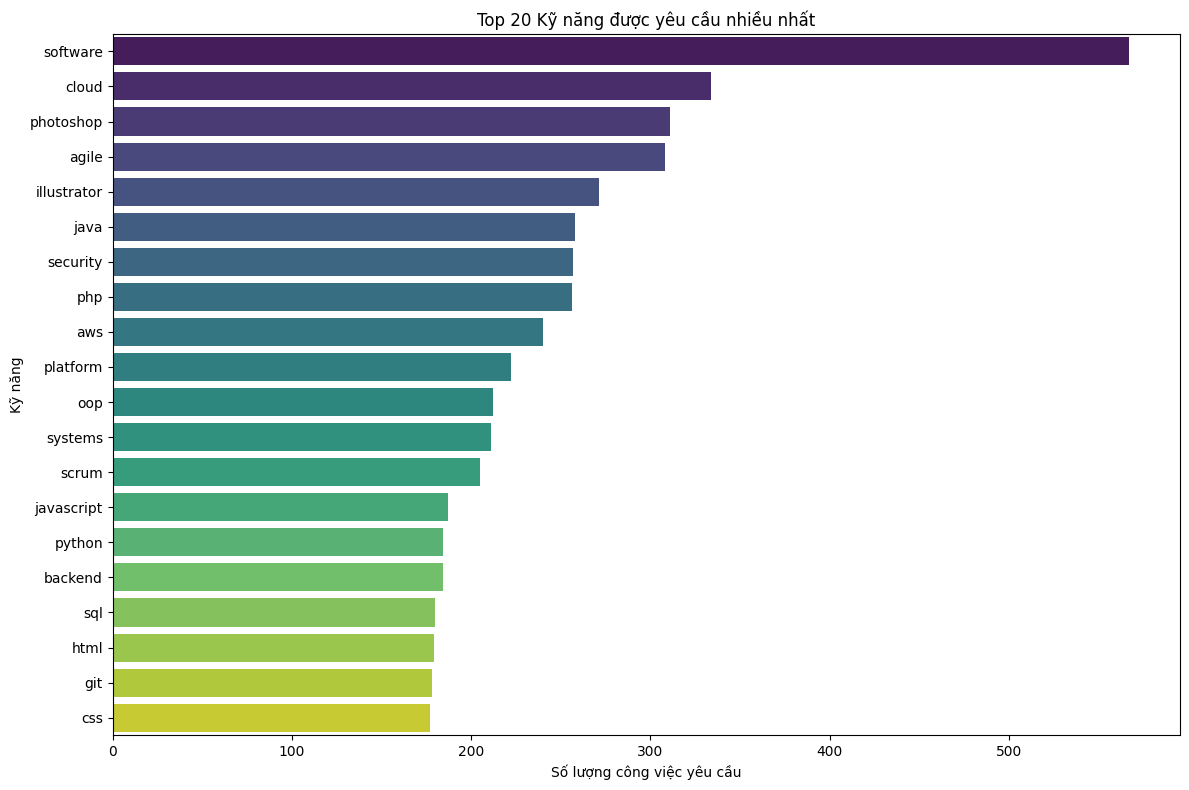

In [52]:
skills_series = df['primary_skills'].explode().dropna().str.strip()

# Đếm kỹ năng phổ biến nhất
skill_counts = Counter(skills_series)
top_skills = skill_counts.most_common(20)

# Chuyển thành DataFrame để vẽ biểu đồ
skills_df = pd.DataFrame(top_skills, columns=['Skill', 'Count'])

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Skill', data=skills_df, palette='viridis')
plt.title('Top 20 Kỹ năng được yêu cầu nhiều nhất')
plt.xlabel('Số lượng công việc yêu cầu')
plt.ylabel('Kỹ năng')
plt.tight_layout()
plt.show()

In [53]:
pd.DataFrame(df)

,id,title,company,location,salary,work_type,description,requirements,skills,category,language,description_clean,requirements_clean,description_en_clean,requirements_en_clean,primary_skills,secondary_skills,adjectives,adverbs
0,JOB_0,MLops Engineer,Trusting Social,Ho Chi Minh,You'll love it,Not specified,We are looking for qualified MLops Engineer fo...,BS or MS in Computer Science or related fields...,"MLOps, Python, Linux, Docker, Data Science, Te...",None,en,we are looking for qualified mlops engineer fo...,bs or ms in computer science or related fields...,we are looking for qualified mlops engineer fo...,bs or ms in computer science or related fields...,"[python, java, javascript, c++, tensorflow, py...","[computer vision, backend, mobile, data scient...","[qualified, familiar, digital, primary, great,...",[]
1,JOB_1,"Senior DevOps Engineer (Cloud, AWS)",TymeX,Ho Chi Minh,You'll love it,Not specified,We are seeking an experienced Senior DevOps En...,Requirements:\r\nBachelor's or Master's degree...,"AWS, DevOps, Cloud, Cloud-native Architecture,...",DevOps / MLOps / SysOps,en,we are seeking an experienced senior devops en...,requirements or degree in computer science inf...,we are seeking an experienced senior devops en...,requirements or degree in computer science inf...,"[python, bash, aws, ci cd, devops, devops engi...","[automation, aws, software, devops, devops eng...","[agile, professional, rapid, experienced, tech...","[occasionally, quickly, independently, effecti..."
2,JOB_2,VTS - Chuyên Viên Quản Trị Dự Án (Agile/ Azure),Viettel Group,Ha Noi,You'll love it,Not specified,Ecotek đang dẫn dắt Ecopark phát triển trở thà...,"Tư duy logic tốt, tư duy hướng giải pháp, tư d...","Project Management, Business Analysis, Presale...",None,vi,ecotek đang dẫn dắt ecopark phát triển trở thà...,tư duy logic tốt tư duy hướng giải pháp tư duy...,Ecotek is leading Ecopark to become a smart ci...,Good logical thinking of thinking solutions to...,"[software, sales]","[software, network, project manager]","[digital, important, smart, urban, logical, sp...","[currently, clearly, directly]"
3,JOB_3,VTS - Tư Vấn Giải Pháp - Presales Engineer,Viettel Group,Ha Noi,You'll love it,Not specified,"Gia nhập “vũ trụ” công nghệ Viettel, nơi bạn k...",Bằng cấp: Tốt nghiệp Đại học (loại Khá trở lên...,"Presale, Business Analysis, Salesforce, Pre-sa...",None,vi,gia nhập vũ trụ công nghệ viettel nơi bạn khôn...,bằng cấp tốt nghiệp đại học loại khá trở lên c...,Joining the Viettel technology space where you...,Graduation degree with a good or higher degree...,[],"[cloud, ai, blockchain, iot]","[important, industrial, specialized, mental, t...",[]
4,JOB_4,"VHT - Embedded Software Engineer (Linux, C++)",Viettel Group,Ha Noi,"650 - 2,200 USD",Not specified,"Với hơn 1200 nhân sự chất lượng cao , Tổng Côn...",Tốt nghiệp Đại học chính quy loại Khá trở lên ...,"Embedded, C++, Linux, C language, Embedded Eng...",Embedded / IoT,vi,với hơn 1200 nhân sự chất lượng cao tổng công ...,tốt nghiệp đại học chính quy loại khá trở lên ...,With more than 1200 high quality personnel Vie...,"Graduated with a regular university or higher,...",[linux],"[mobile, network, security, embedded, systems]","[optical, high, core, military, vietnamese, go...",[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,JOB_2507,Chuyên Graphic Designer,CÔNG TY CỔ PHẦN KHOA HỌC KỸ THUẬT SAO XANH,Hồ Chí Minh,10 - 25 triệu,None,--- Mô tả công việc ---\n- Thiết kế ấn phẩm tr...,"Sử Dụng Thành Thạo Photoshop, Sử Dụng Thành Th...",None,UI‑UX / Graphic Design,vi,mô tả công việc - thiết kế ấn phẩm truyền thôn...,sử dụng thành thạo photoshop sử dụng thành thạ...,Job description - Designing Banner Poster Comm...,Proficient use of Photoshop is proficient in u...,"[illustrator, photoshop]",[designer],"[artistic, relevant, dynamic, right, synchrono...","[right, online, proficiently]"
2508,JOB_2508,CTV Quản Lý Dự Án,Công ty CP An ninh mạng Việt Nam,Hà Nội,Thoả thuận,None,--

In [54]:
df.to_csv('../../data/clean/clean_jobs_v2.csv', index=False, encoding='utf-8')